# Optional Lab: Gradient Descent for Linear Regression

<figure>
    <center> <img src="./images/C1_W1_L4_S1_Lecture_GD.png"  style="width:800px;height:200px;" ></center>
</figure>

## Goals
In this lab, you will:
- automate the process of optimizing $w$ and $b$ using gradient descent.

## Tools
In this lab, we will make use of: 
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data
- plotting routines in the lab_utils.py file in the local directory

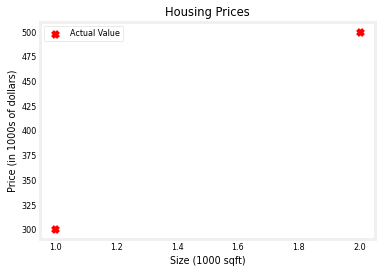

In [2]:
# Importando bibliotecas essenciais
import numpy as np
import matplotlib.pyplot as plt

# Configurando o estilo de gráficos
plt.style.use('./deeplearning.mplstyle')

# Importando funções utilitárias
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

# Dados de entrada fornecidos no exercício
x_train = np.array([1.0, 2.0])  # Tamanho da casa em milhares de pés quadrados
y_train = np.array([300.0, 500.0])  # Preço em milhares de dólares

# Função para calcular o custo
def compute_cost(x, y, w, b):
    """
    Calcula o custo da regressão linear.
    
    Args:
    x (array): Conjunto de entradas.
    y (array): Conjunto de saídas.
    w (float): Peso da regressão.
    b (float): Intercepto (bias).
    
    Returns:
    float: Valor do custo.
    """
    m = x.shape[0]  # Número de exemplos
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b  # Previsão
        cost += (f_wb - y[i]) ** 2
    return cost / (2 * m)

# Visualização inicial dos dados
plt_house_x(x_train, y_train)  # Apenas os dados de entrada e saída

<a name="toc_40291_2"></a>
# Problem Statement

Let's use the same two data points as before - a house with 1000 square feet sold for \\$300,000 and a house with 2000 square feet sold for \\$500,000.

| Size (1000 sqft)     | Price (1000s of dollars) |
| ----------------| ------------------------ |
| 1               | 300                      |
| 2               | 500                      |


✅ Dados carregados com sucesso:
🏠 Tamanhos das casas (x_train): [1. 2.] (em milhares de pés quadrados)
💲 Preços das casas (y_train): [300. 500.] (em milhares de dólares)


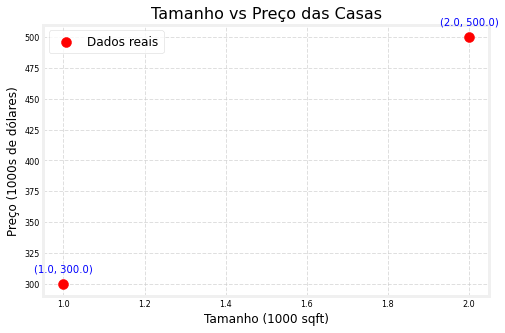

In [4]:
# Carregando os dados do conjunto de treinamento
x_train = np.array([1.0, 2.0])  # Tamanho da casa (1000 e 2000 pés quadrados)
y_train = np.array([300.0, 500.0])  # Preço da casa (300 mil e 500 mil dólares)

# Impressão dos dados para conferência
print("✅ Dados carregados com sucesso:")
print(f"🏠 Tamanhos das casas (x_train): {x_train} (em milhares de pés quadrados)")
print(f"💲 Preços das casas (y_train): {y_train} (em milhares de dólares)")

# Visualização inicial dos dados
plt.figure(figsize=(8, 5))  # Define o tamanho do gráfico
plt.scatter(x_train, y_train, color='red', label='Dados reais', s=100)  # Gráfico de dispersão

# Adiciona valores nos pontos
for i in range(len(x_train)):
    plt.text(x_train[i], y_train[i] + 10, f"({x_train[i]}, {y_train[i]})", fontsize=10, color="blue", ha='center')

# Configurações do gráfico
plt.title("Tamanho vs Preço das Casas", fontsize=16)
plt.xlabel("Tamanho (1000 sqft)", fontsize=12)
plt.ylabel("Preço (1000s de dólares)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)  # Adiciona uma grade para facilitar a leitura
plt.legend(fontsize=12)
plt.show()

<a name="toc_40291_2.0.1"></a>
### Compute_Cost
This was developed in the last lab. We'll need it again here.

In [5]:
def compute_gradient(x, y, w, b):
    """
    Calcula os gradientes da função de custo em relação a w e b.
    
    Args:
    x (array): Conjunto de entradas.
    y (array): Conjunto de saídas.
    w (float): Peso da regressão.
    b (float): Intercepto (bias).
    
    Returns:
    tuple: Gradientes em relação a w (dj_dw) e b (dj_db).
    """
    m = x.shape[0]  # Número de exemplos
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

def gradient_descent(x, y, w, b, alpha, num_iters):
    """
    Executa o gradiente descendente para minimizar o custo.
    
    Args:
    x (array): Conjunto de entradas.
    y (array): Conjunto de saídas.
    w (float): Peso inicial.
    b (float): Intercepto inicial.
    alpha (float): Taxa de aprendizado.
    num_iters (int): Número de iterações.
    
    Returns:
    tuple: Peso e intercepto otimizados.
    """
    for i in range(num_iters):
        # Calcula os gradientes
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        # Atualiza w e b
        w -= alpha * dj_dw
        b -= alpha * dj_db

        # (Opcional) Exibe o progresso a cada 100 iterações
        if i % 100 == 0:
            cost = compute_cost(x, y, w, b)
            print(f"Iteração {i}: Custo {cost:.4f}, w {w:.4f}, b {b:.4f}")

    return w, b

<a name="toc_40291_2.1"></a>
## Gradient descent summary
So far in this course, you have developed a linear model that predicts $f_{w,b}(x^{(i)})$:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2\tag{2}$$ 


In lecture, *gradient descent* was described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaniously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

<a name="toc_40291_2.2"></a>
## Implement Gradient Descent
You will implement gradient descent algorithm for one feature. You will need three functions. 
- `compute_gradient` implementing equation (4) and (5) above
- `compute_cost` implementing equation (2) above (code from previous lab)
- `gradient_descent`, utilizing compute_gradient and compute_cost

Conventions:
- The naming of python variables containing partial derivatives follows this pattern,$\frac{\partial J(w,b)}{\partial b}$  will be `dj_db`.
- w.r.t is With Respect To, as in partial derivative of $J(wb)$ With Respect To $b$.


<a name="toc_40291_2.3"></a>
### compute_gradient
<a name='ex-01'></a>
`compute_gradient`  implements (4) and (5) above and returns $\frac{\partial J(w,b)}{\partial w}$,$\frac{\partial J(w,b)}{\partial b}$. The embedded comments describe the operations.

In [14]:
# Dados de exemplo
x_train = np.array([1.0, 2.0, 3.0])  # Tamanhos das casas
y_train = np.array([300.0, 500.0, 700.0])  # Preços das casas
w = 100  # Peso inicial (exemplo arbitrário)
b = 0    # Intercepto inicial

# Calculando gradientes usando compute_gradient
dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)

# Impressão dos gradientes calculados
print("Gradientes calculados:")
print(f"Gradiente em relação a w (dj_dw): {dj_dw:.4f}")
print(f"Gradiente em relação a b (dj_db): {dj_db:.4f}")

# Aplicando uma etapa do gradiente descendente para mostrar como w e b são atualizados
alpha = 0.01  # Taxa de aprendizado
w_updated = w - alpha * dj_dw
b_updated = b - alpha * dj_db

# Exibindo os novos valores de w e b
print("\nApós uma etapa de gradiente descendente:")
print(f"Novo w: {w_updated:.4f}")
print(f"Novo b: {b_updated:.4f}")

Gradientes calculados:
Gradiente em relação a w (dj_dw): -666.6667
Gradiente em relação a b (dj_db): -300.0000

Após uma etapa de gradiente descendente:
Novo w: 106.6667
Novo b: 3.0000


<br/>

<img align="left" src="./images/C1_W1_Lab03_lecture_slopes.PNG"   style="width:340px;" > The lectures described how gradient descent utilizes the partial derivative of the cost with respect to a parameter at a point to update that parameter.   
Let's use our `compute_gradient` function to find and plot some partial derivatives of our cost function relative to one of the parameters, $w_0$.


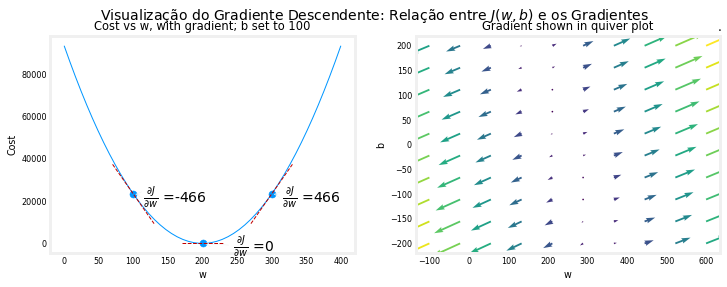

In [15]:
plt_gradients(x_train, y_train, compute_cost, compute_gradient)

# Adicionando título global aos gráficos
plt.suptitle(
    "Visualização do Gradiente Descendente: Relação entre $J(w, b)$ e os Gradientes", 
    fontsize=14
)

plt.show()

Above, the left plot shows $\frac{\partial J(w,b)}{\partial w}$ or the slope of the cost curve relative to $w$ at three points. On the right side of the plot, the derivative is positive, while on the left it is negative. Due to the 'bowl shape', the derivatives will always lead gradient descent toward the bottom where the gradient is zero.
 
The left plot has fixed $b=100$. Gradient descent will utilize both $\frac{\partial J(w,b)}{\partial w}$ and $\frac{\partial J(w,b)}{\partial b}$ to update parameters. The 'quiver plot' on the right provides a means of viewing the gradient of both parameters. The arrow sizes reflect the magnitude of the gradient at that point. The direction and slope of the arrow reflects the ratio of $\frac{\partial J(w,b)}{\partial w}$ and $\frac{\partial J(w,b)}{\partial b}$ at that point.
Note that the gradient points *away* from the minimum. Review equation (3) above. The scaled gradient is *subtracted* from the current value of $w$ or $b$. This moves the parameter in a direction that will reduce cost.

<a name="toc_40291_2.5"></a>
###  Gradient Descent
Now that gradients can be computed,  gradient descent, described in equation (3) above can be implemented below in `gradient_descent`. The details of the implementation are described in the comments. Below, you will utilize this function to find optimal values of $w$ and $b$ on the training data.

In [17]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    """
    Executa o gradiente descendente para ajustar os parâmetros w e b.
    Atualiza w e b ao realizar num_iters passos de gradiente com uma taxa de aprendizado alpha.

    Args:
      x (ndarray (m,)): Dados de entrada, m exemplos.
      y (ndarray (m,)): Valores-alvo (targets).
      w_in, b_in (float): Valores iniciais dos parâmetros do modelo.
      alpha (float): Taxa de aprendizado.
      num_iters (int): Número de iterações para executar o gradiente descendente.
      cost_function: Função usada para calcular o custo.
      gradient_function: Função usada para calcular os gradientes.

    Returns:
      w (float): Valor atualizado de w após o gradiente descendente.
      b (float): Valor atualizado de b após o gradiente descendente.
      J_history (list): Histórico dos valores de custo \( J(w, b) \).
      p_history (list): Histórico dos parâmetros [w, b].
    """
    
    # Inicializando arrays para armazenar o histórico do custo e dos parâmetros
    J_history = []  # Histórico dos valores do custo
    p_history = []  # Histórico dos parâmetros [w, b]
    b = b_in        # Inicializando b com o valor inicial fornecido
    w = w_in        # Inicializando w com o valor inicial fornecido
    
    # Loop principal para realizar as iterações do gradiente descendente
    for i in range(num_iters):
        # Calcula os gradientes em relação a w e b usando a gradient_function
        dj_dw, dj_db = gradient_function(x, y, w, b)

        # Atualiza os parâmetros w e b usando as equações do gradiente descendente
        b = b - alpha * dj_db  # Atualiza b com base na taxa de aprendizado e gradiente
        w = w - alpha * dj_dw  # Atualiza w com base na taxa de aprendizado e gradiente

        # Armazena o custo e os parâmetros para análise posterior
        if i < 100000:  # Evita exaustão de recursos (limita o número de registros no histórico)
            J_history.append(cost_function(x, y, w, b))  # Calcula e armazena o custo atual
            p_history.append([w, b])  # Armazena os parâmetros atuais

        # Exibe informações sobre o progresso em intervalos regulares
        if i % math.ceil(num_iters / 10) == 0:  # Exibe progresso 10 vezes ao longo das iterações
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b: {b: 0.5e}")

    # Retorna os valores finais de w e b, além do histórico do custo e dos parâmetros
    return w, b, J_history, p_history

Iteration    0: Cost 1.23e+05  dj_dw: -1.133e+03, dj_db: -5.000e+02   w:  1.133e+01, b:  5.00000e+00
Iteration 1000: Cost 6.55e-01  dj_dw:  1.600e-01, dj_db: -3.636e-01   w:  2.013e+02, b:  9.69785e+01
Iteration 2000: Cost 5.91e-02  dj_dw:  4.805e-02, dj_db: -1.092e-01   w:  2.004e+02, b:  9.90924e+01
Iteration 3000: Cost 5.33e-03  dj_dw:  1.443e-02, dj_db: -3.281e-02   w:  2.001e+02, b:  9.97274e+01
Iteration 4000: Cost 4.81e-04  dj_dw:  4.335e-03, dj_db: -9.855e-03   w:  2.000e+02, b:  9.99181e+01
Iteration 5000: Cost 4.34e-05  dj_dw:  1.302e-03, dj_db: -2.960e-03   w:  2.000e+02, b:  9.99754e+01
Iteration 6000: Cost 3.92e-06  dj_dw:  3.912e-04, dj_db: -8.893e-04   w:  2.000e+02, b:  9.99926e+01
Iteration 7000: Cost 3.53e-07  dj_dw:  1.175e-04, dj_db: -2.671e-04   w:  2.000e+02, b:  9.99978e+01
Iteration 8000: Cost 3.19e-08  dj_dw:  3.530e-05, dj_db: -8.024e-05   w:  2.000e+02, b:  9.99993e+01
Iteration 9000: Cost 2.88e-09  dj_dw:  1.060e-05, dj_db: -2.410e-05   w:  2.000e+02, b:  9.

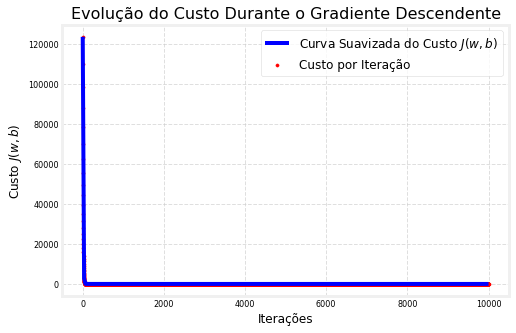

In [21]:
import math  # Certifique-se de importar a biblioteca math

# Inicializando os parâmetros
w_init = 0.0  # Peso inicial
b_init = 0.0  # Intercepto inicial
# Configuração do gradiente descendente
iterations = 10000  # Número de iterações
tmp_alpha = 1.0e-2  # Taxa de aprendizado (learning rate)

# Executando o gradiente descendente
w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient
)

# Exibindo os valores finais de w e b
print(f"Parâmetros encontrados pelo gradiente descendente:")
print(f"w (peso final): {w_final:8.4f}")
print(f"b (intercepto final): {b_final:8.4f}")

# Visualizando a evolução do custo com uma curva contínua
plt.figure(figsize=(8, 5))

# Linha curva para suavizar a transição dos pontos
from scipy.interpolate import make_interp_spline
x_iter = range(len(J_hist))
x_new = np.linspace(0, len(J_hist), 300)  # Cria um domínio mais denso para suavizar
J_smooth = make_interp_spline(x_iter, J_hist)(x_new)  # Suaviza os dados do custo

# Gráfico do custo
plt.plot(x_new, J_smooth, label="Curva Suavizada do Custo $J(w, b)$", color="blue")
plt.scatter(x_iter, J_hist, color="red", s=10, label="Custo por Iteração")  # Pontos reais

plt.title("Evolução do Custo Durante o Gradiente Descendente", fontsize=16)
plt.xlabel("Iterações", fontsize=12)
plt.ylabel("Custo $J(w, b)$", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()

<img align="left" src="./images/C1_W1_Lab03_lecture_learningrate.PNG"  style="width:340px; padding: 15px; " > 
Take a moment and note some characteristics of the gradient descent process printed above.  

- The cost starts large and rapidly declines as described in the slide from the lecture.
- The partial derivatives, `dj_dw`, and `dj_db` also get smaller, rapidly at first and then more slowly. As shown in the diagram from the lecture, as the process nears the 'bottom of the bowl' progress is slower due to the smaller value of the derivative at that point.
- progress slows though the learning rate, alpha, remains fixed

### Cost versus iterations of gradient descent 
A plot of cost versus iterations is a useful measure of progress in gradient descent. Cost should always decrease in successful runs. The change in cost is so rapid initially, it is useful to plot the initial decent on a different scale than the final descent. In the plots below, note the scale of cost on the axes and the iteration step.

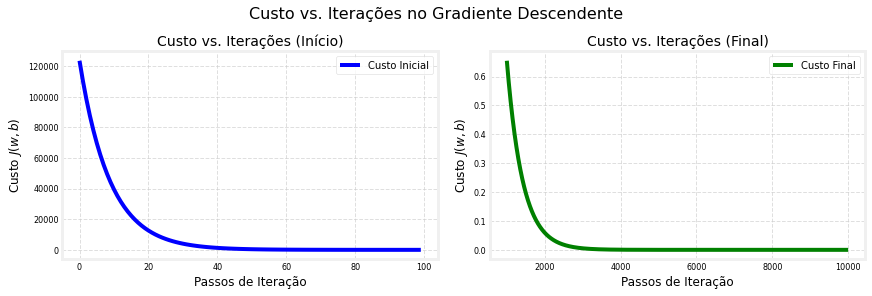

In [22]:
# Plotando o custo versus iterações
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))

# Gráfico 1: Primeiras 100 iterações
ax1.plot(J_hist[:100], color="blue", label="Custo Inicial")
ax1.set_title("Custo vs. Iterações (Início)", fontsize=14)
ax1.set_xlabel("Passos de Iteração", fontsize=12)
ax1.set_ylabel("Custo $J(w, b)$", fontsize=12)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(fontsize=10)

# Gráfico 2: Últimas 1000 iterações
ax2.plot(range(1000, 1000 + len(J_hist[1000:])), J_hist[1000:], color="green", label="Custo Final")
ax2.set_title("Custo vs. Iterações (Final)", fontsize=14)
ax2.set_xlabel("Passos de Iteração", fontsize=12)
ax2.set_ylabel("Custo $J(w, b)$", fontsize=12)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(fontsize=10)

# Exibindo os gráficos
plt.suptitle("Custo vs. Iterações no Gradiente Descendente", fontsize=16)
plt.show()

### Predictions
Now that you have discovered the optimal values for the parameters $w$ and $b$, you can now use the model to predict housing values based on our learned parameters. As expected, the predicted values are nearly the same as the training values for the same housing. Further, the value not in the prediction is in line with the expected value.

In [23]:
# Previsões baseadas nos valores otimizados de w e b
print("Previsões de Preços de Casas:")
sizes = [1.0, 1.2, 2.0]  # Tamanhos em milhares de pés quadrados (1000, 1200, 2000 sqft)
for size in sizes:
    price = w_final * size + b_final
    print(f"Casa com {int(size * 1000)} sqft: Preço previsto = {price:0.1f} mil dólares")

Previsões de Preços de Casas:
Casa com 1000 sqft: Preço previsto = 300.0 mil dólares
Casa com 1200 sqft: Preço previsto = 340.0 mil dólares
Casa com 2000 sqft: Preço previsto = 500.0 mil dólares


<a name="toc_40291_2.6"></a>
## Plotting
You can show the progress of gradient descent during its execution by plotting the cost over iterations on a contour plot of the cost(w,b). 

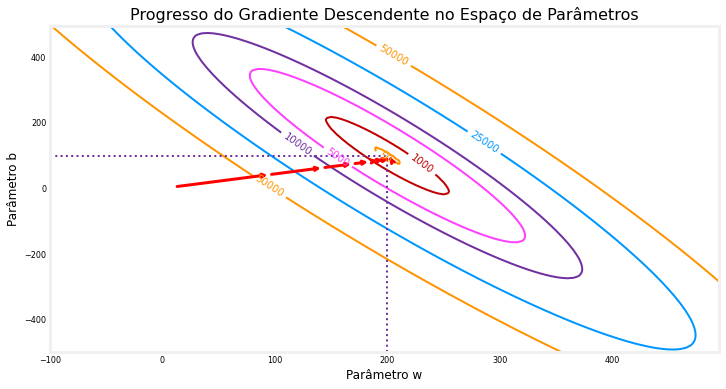

In [24]:
# Configurando o gráfico de contorno para visualizar o gradiente descendente
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Utilizando a função fornecida para exibir o contorno e o caminho do gradiente descendente
plt_contour_wgrad(x_train, y_train, p_hist, ax)

# Ajustando título e detalhes do gráfico
ax.set_title("Progresso do Gradiente Descendente no Espaço de Parâmetros", fontsize=16)
ax.set_xlabel("Parâmetro w", fontsize=12)
ax.set_ylabel("Parâmetro b", fontsize=12)

plt.show()

Above, the contour plot shows the $cost(w,b)$ over a range of $w$ and $b$. Cost levels are represented by the rings. Overlayed, using red arrows, is the path of gradient descent. Here are some things to note:
- The path makes steady (monotonic) progress toward its goal.
- initial steps are much larger than the steps near the goal.

**Zooming in**, we can see that final steps of gradient descent. Note the distance between steps shrinks as the gradient approaches zero.

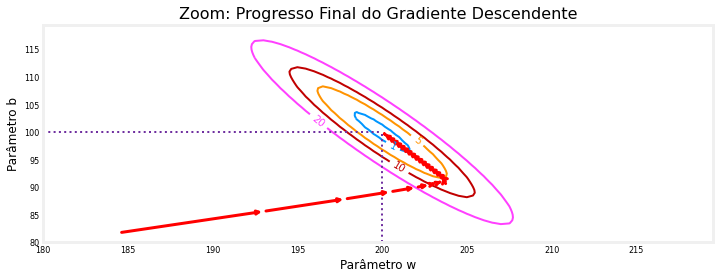

In [25]:
# Plotando o contorno com zoom nas etapas finais
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Chamando a função de contorno com parâmetros refinados
plt_contour_wgrad(
    x_train, y_train, p_hist, ax,
    w_range=[180, 220, 0.5],  # Intervalo para w
    b_range=[80, 120, 0.5],   # Intervalo para b
    contours=[1, 5, 10, 20],  # Níveis de contorno
    resolution=0.5            # Resolução
)

# Ajustando título e rótulos
ax.set_title("Zoom: Progresso Final do Gradiente Descendente", fontsize=16)
ax.set_xlabel("Parâmetro w", fontsize=12)
ax.set_ylabel("Parâmetro b", fontsize=12)

plt.show()

<a name="toc_40291_2.7.1"></a>
### Increased Learning Rate

<figure>
 <img align="left", src="./images/C1_W1_Lab03_alpha_too_big.PNG"   style="width:340px;height:240px;" >
</figure>
In the lecture, there was a discussion related to the proper value of the learning rate, $\alpha$ in equation(3). The larger $\alpha$ is, the faster gradient descent will converge to a solution. But, if it is too large, gradient descent will diverge. Above you have an example of a solution which converges nicely.

Let's try increasing the value of  $\alpha$ and see what happens:

Iteration    0: Cost 1.63e+06  dj_dw: -1.133e+03, dj_db: -5.000e+02   w:  9.067e+02, b:  4.00000e+02
Iteration    1: Cost 1.93e+07  dj_dw:  3.898e+03, dj_db:  1.713e+03   w: -2.212e+03, b: -9.70667e+02
Iteration    2: Cost 2.28e+08  dj_dw: -1.340e+04, dj_db: -5.894e+03   w:  8.505e+03, b:  3.74436e+03
Iteration    3: Cost 2.69e+09  dj_dw:  4.604e+04, dj_db:  2.025e+04   w: -2.833e+04, b: -1.24586e+04
Iteration    4: Cost 3.18e+10  dj_dw: -1.583e+05, dj_db: -6.962e+04   w:  9.828e+04, b:  4.32368e+04
Iteration    5: Cost 3.76e+11  dj_dw:  5.440e+05, dj_db:  2.393e+05   w: -3.369e+05, b: -1.48195e+05
Iteration    6: Cost 4.44e+12  dj_dw: -1.870e+06, dj_db: -8.225e+05   w:  1.159e+06, b:  5.09793e+05
Iteration    7: Cost 5.25e+13  dj_dw:  6.426e+06, dj_db:  2.827e+06   w: -3.982e+06, b: -1.75183e+06
Iteration    8: Cost 6.20e+14  dj_dw: -2.209e+07, dj_db: -9.717e+06   w:  1.369e+07, b:  6.02176e+06
Iteration    9: Cost 7.33e+15  dj_dw:  7.592e+07, dj_db:  3.340e+07   w: -4.705e+07, b: -2.

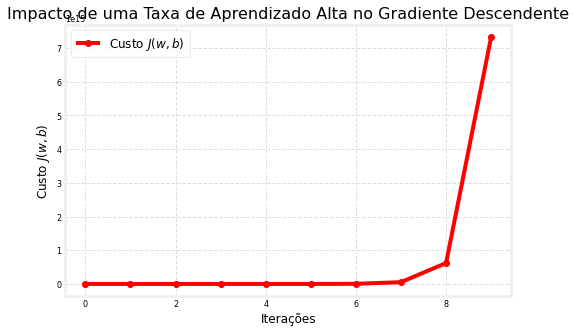

In [26]:
# Inicializando os parâmetros
w_init = 0.0  # Peso inicial
b_init = 0.0  # Intercepto inicial
# Definindo uma taxa de aprendizado alta
iterations = 10  # Número de iterações (reduzido para observar rapidamente o comportamento)
tmp_alpha = 8.0e-1  # Taxa de aprendizado alta

# Executando o gradiente descendente
w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train, y_train, w_init, b_init, tmp_alpha, iterations, compute_cost, compute_gradient
)

# Exibindo os valores finais
print(f"Parâmetros finais encontrados:")
print(f"w: {w_final:.4f}, b: {b_final:.4f}")

# Plotando o custo para verificar o impacto da taxa de aprendizado
plt.figure(figsize=(8, 5))
plt.plot(range(len(J_hist)), J_hist, marker='o', label="Custo $J(w, b)$", color="red")
plt.title("Impacto de uma Taxa de Aprendizado Alta no Gradiente Descendente", fontsize=16)
plt.xlabel("Iterações", fontsize=12)
plt.ylabel("Custo $J(w, b)$", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=12)
plt.show()

Above, $w$ and $b$ are bouncing back and forth between positive and negative with the absolute value increasing with each iteration. Further, each iteration $\frac{\partial J(w,b)}{\partial w}$ changes sign and cost is increasing rather than decreasing. This is a clear sign that the *learning rate is too large* and the solution is diverging. 
Let's visualize this with a plot.

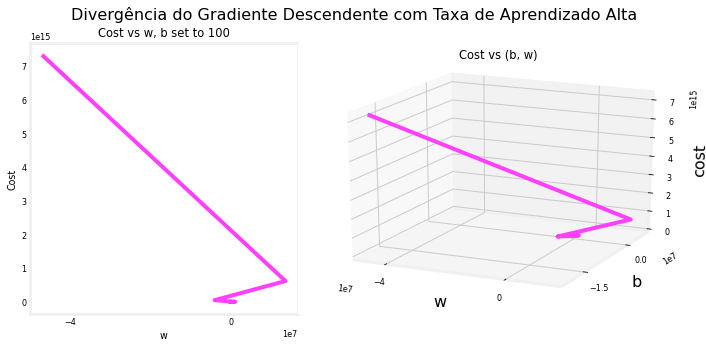

In [27]:
# Visualizando a divergência causada por uma taxa de aprendizado alta
plt_divergence(p_hist, J_hist, x_train, y_train)

# Ajustando o título e exibindo o gráfico
plt.suptitle("Divergência do Gradiente Descendente com Taxa de Aprendizado Alta", fontsize=16)
plt.show()

Above, the left graph shows $w$'s progression over the first few steps of gradient descent. $w$ oscillates from positive to negative and cost grows rapidly. Gradient Descent is operating on both $w$ and $b$ simultaneously, so one needs the 3-D plot on the right for the complete picture.


## Congratulations!
In this lab you:
- delved into the details of gradient descent for a single variable.
- developed a routine to compute the gradient
- visualized what the gradient is
- completed a gradient descent routine
- utilized gradient descent to find parameters
- examined the impact of sizing the learning rate

Iteração    0: Custo 7.93e+04, dj_dw: -6.500e+02, dj_db: -4.000e+02, w:  6.500e+00, b:  4.00000e+00
Iteração 1000: Custo 3.41e+00, dj_dw: -3.712e-01, dj_db:  6.007e-01, w:  1.949e+02, b:  1.08228e+02
Iteração 2000: Custo 7.93e-01, dj_dw: -1.789e-01, dj_db:  2.895e-01, w:  1.975e+02, b:  1.03966e+02
Iteração 3000: Custo 1.84e-01, dj_dw: -8.625e-02, dj_db:  1.396e-01, w:  1.988e+02, b:  1.01912e+02
Iteração 4000: Custo 4.28e-02, dj_dw: -4.158e-02, dj_db:  6.727e-02, w:  1.994e+02, b:  1.00922e+02
Iteração 5000: Custo 9.95e-03, dj_dw: -2.004e-02, dj_db:  3.243e-02, w:  1.997e+02, b:  1.00444e+02
Iteração 6000: Custo 2.31e-03, dj_dw: -9.660e-03, dj_db:  1.563e-02, w:  1.999e+02, b:  1.00214e+02
Iteração 7000: Custo 5.37e-04, dj_dw: -4.657e-03, dj_db:  7.535e-03, w:  1.999e+02, b:  1.00103e+02
Iteração 8000: Custo 1.25e-04, dj_dw: -2.245e-03, dj_db:  3.632e-03, w:  2.000e+02, b:  1.00050e+02
Iteração 9000: Custo 2.90e-05, dj_dw: -1.082e-03, dj_db:  1.751e-03, w:  2.000e+02, b:  1.00024e+02


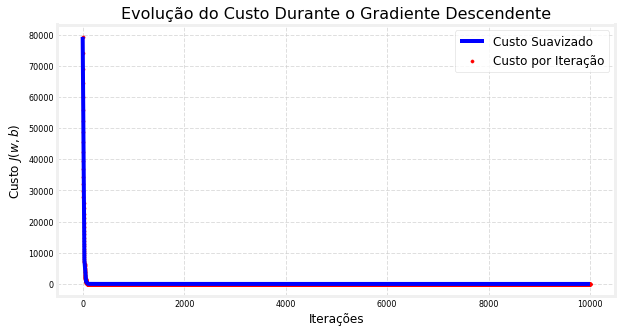


Previsões de preços de casas:
Casa com 1000 sqft: Preço previsto = 300.00 mil dólares
Casa com 1200 sqft: Preço previsto = 340.00 mil dólares
Casa com 2000 sqft: Preço previsto = 500.00 mil dólares


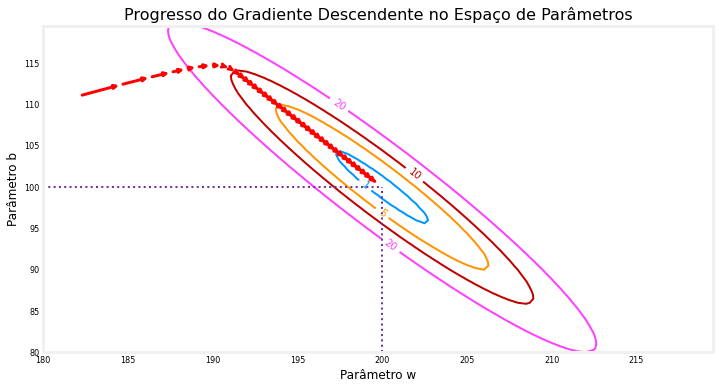

Iteração    0: Custo 2.58e+05, dj_dw: -6.500e+02, dj_db: -4.000e+02, w:  5.200e+02, b:  3.20000e+02
Iteração    1: Custo 7.82e+05, dj_dw:  1.130e+03, dj_db:  7.000e+02, w: -3.840e+02, b: -2.40000e+02
Iteração    2: Custo 2.37e+06, dj_dw: -1.970e+03, dj_db: -1.216e+03, w:  1.192e+03, b:  7.32800e+02
Iteração    3: Custo 7.19e+06, dj_dw:  3.429e+03, dj_db:  2.121e+03, w: -1.551e+03, b: -9.63840e+02
Iteração    4: Custo 2.18e+07, dj_dw: -5.974e+03, dj_db: -3.691e+03, w:  3.228e+03, b:  1.98886e+03
Iteração    5: Custo 6.62e+07, dj_dw:  1.040e+04, dj_db:  6.431e+03, w: -5.095e+03, b: -3.15579e+03
Iteração    6: Custo 2.01e+08, dj_dw: -1.812e+04, dj_db: -1.120e+04, w:  9.402e+03, b:  5.80237e+03
Iteração    7: Custo 6.09e+08, dj_dw:  3.156e+04, dj_db:  1.950e+04, w: -1.584e+04, b: -9.80139e+03
Iteração    8: Custo 1.85e+09, dj_dw: -5.496e+04, dj_db: -3.397e+04, w:  2.813e+04, b:  1.73730e+04
Iteração    9: Custo 5.60e+09, dj_dw:  9.572e+04, dj_db:  5.916e+04, w: -4.845e+04, b: -2.99567e+04


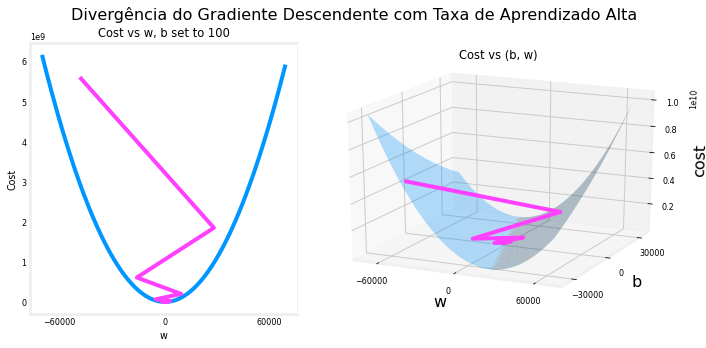

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.interpolate import make_interp_spline

# Função para calcular o custo
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i])**2
    total_cost = cost / (2 * m)
    return total_cost

# Função para calcular o gradiente
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw += (f_wb - y[i]) * x[i]
        dj_db += (f_wb - y[i])
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

# Função para executar o gradiente descendente
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    J_history = []
    p_history = []
    w = w_in
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i < 100000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteração {i:4}: Custo {J_history[-1]:0.2e}, dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}, w: {w: 0.3e}, b: {b: 0.5e}")
    return w, b, J_history, p_history

# Dados de treinamento
x_train = np.array([1.0, 2.0])  # Tamanho em milhares de pés quadrados
y_train = np.array([300.0, 500.0])  # Preço em milhares de dólares

# Inicialização dos parâmetros
w_init = 0.0
b_init = 0.0
iterations = 10000
alpha = 1.0e-2

# Executando o gradiente descendente
w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train, y_train, w_init, b_init, alpha, iterations, compute_cost, compute_gradient
)

# Exibindo os valores finais
print("\nParâmetros finais encontrados:")
print(f"w: {w_final:.4f}, b: {b_final:.4f}")

# Visualização do custo ao longo das iterações
plt.figure(figsize=(10, 5))
x_iter = range(len(J_hist))
x_new = np.linspace(0, len(J_hist), 300)
J_smooth = make_interp_spline(x_iter, J_hist)(x_new)
plt.plot(x_new, J_smooth, label="Custo Suavizado", color="blue")
plt.scatter(x_iter, J_hist, color="red", s=10, label="Custo por Iteração")
plt.title("Evolução do Custo Durante o Gradiente Descendente", fontsize=16)
plt.xlabel("Iterações", fontsize=12)
plt.ylabel("Custo $J(w, b)$", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Previsões
print("\nPrevisões de preços de casas:")
sizes = [1.0, 1.2, 2.0]
for size in sizes:
    price = w_final * size + b_final
    print(f"Casa com {int(size * 1000)} sqft: Preço previsto = {price:.2f} mil dólares")

# Gráfico de contorno do gradiente descendente
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plt_contour_wgrad(x_train, y_train, p_hist, ax, w_range=[180, 220, 0.5], b_range=[80, 120, 0.5], contours=[1, 5, 10, 20], resolution=0.5)
ax.set_title("Progresso do Gradiente Descendente no Espaço de Parâmetros", fontsize=16)
ax.set_xlabel("Parâmetro w", fontsize=12)
ax.set_ylabel("Parâmetro b", fontsize=12)
plt.show()

# Visualização da divergência para taxa de aprendizado alta
tmp_alpha = 8.0e-1
_, _, J_hist_high_alpha, p_hist_high_alpha = gradient_descent(
    x_train, y_train, w_init, b_init, tmp_alpha, 10, compute_cost, compute_gradient
)
plt_divergence(p_hist_high_alpha, J_hist_high_alpha, x_train, y_train)
plt.suptitle("Divergência do Gradiente Descendente com Taxa de Aprendizado Alta", fontsize=16)
plt.show()